# Ranked Sector Allocation: Live vs Research Audit

This notebook compares the live trading implementation (`ranked_asset_alloc.py`)
against the research backtest pipeline (`v10_research_pipeline.py`) to identify
signal drift, execution gaps, and PnL forensics.

Sections:
1. Setup and data loading
2. Side-by-side signal comparison (live vs research functions)
3. Target vs actual holdings analysis
4. Live PnL forensics from order tape
5. Data sensitivity: 2y unadjusted vs 10y+ adjusted
6. Decision memo

In [1]:
# Setup
import os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

REPO_ROOT = os.path.abspath('../../..')
ORDERS_CSV = os.path.join(REPO_ROOT, 'Assignment_final', 'data', 'orders_latest.csv')
if not os.path.exists(ORDERS_CSV):
    ORDERS_CSV = os.path.join(REPO_ROOT, 'reports', 'orders_latest.csv')

print(f"Orders CSV: {ORDERS_CSV}")
print(f"Exists: {os.path.exists(ORDERS_CSV)}")

Orders CSV: /Users/shazilfarukh/Desktop/Quant_algo_trading/Assignment_final/data/orders_latest.csv
Exists: True


## Side-by-Side Signal Comparison

We run the live strategy functions (`_v4_today`, `_v8aw_today`, `_blend`, `_daf_leverage`)
and the research pipeline functions on the same data snapshot to see where they agree and disagree.

In [2]:
# Import both live and research modules
from strategies.ranks.ranked_asset_alloc import (
    _download_data, _v4_today, _v8aw_today, _blend, _daf_leverage, _regime,
    SECTOR_ETFS, HEDGE_ETFS, BENCHMARK, CASH_ETF, ALL_TICKERS,
    V4_BREADTH, V8_BREADTH,
)
from strategies.ranks.v10_research_pipeline import (
    download_v10_data,
    momentum_signal, ewma_volatility, correlation_signal, trend_signal_atr,
)

# Download data through both paths
print("Downloading via LIVE path (2y, no auto_adjust)...")
live_closes, live_ohlc = _download_data()
print(f"  Live: {len(live_closes)} days, cols={list(live_closes.columns[:5])}...")

print("\nDownloading via RESEARCH path (8y, auto_adjust=True)...")
research_closes, research_ohlc = download_v10_data(start="2018-01-01")
print(f"  Research: {len(research_closes)} days, cols={list(research_closes.columns[:5])}...")


18 Failed downloads:


['GLD', 'XLE', 'XLU', 'TLT', 'XLF', 'FXY', 'XLV', 'XLC', 'FXF', 'XLY', 'XLP', 'XLK', 'XLI', 'SPY', 'XLRE', 'XLB', 'UUP', 'SHY']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


  Live: 0 days, cols=['XLK', 'XLF', 'XLV', 'XLE', 'XLI']...



  Research: 2159 days, cols=['XLK', 'XLF', 'XLV', 'XLE', 'XLI']...


In [3]:
# Run live signals on latest day
live_sector = live_closes[SECTOR_ETFS]
live_idx = len(live_closes) - 1

v4_alloc = _v4_today(live_sector, live_ohlc, live_closes, live_idx)
v8_alloc = _v8aw_today(live_sector, live_ohlc, live_closes, live_idx)
blended = _blend(v4_alloc, v8_alloc)
lev = _daf_leverage(live_closes)

print("=== Live Signal Snapshot (latest day) ===")
print(f"Date: {live_closes.index[-1].date()}")
print(f"V4 regime: {_regime(live_closes, live_idx, V4_BREADTH)}")
print(f"V8 regime: {_regime(live_closes, live_idx, V8_BREADTH)}")
print(f"\nV4 allocation: {dict(sorted(v4_alloc.items(), key=lambda x: -x[1]))}")
print(f"V8 allocation: {dict(sorted(v8_alloc.items(), key=lambda x: -x[1]))}")
print(f"Blended target: {dict(sorted(blended.items(), key=lambda x: -x[1]))}")
print(f"DAF leverage: {lev:.1f}x")

=== Live Signal Snapshot (latest day) ===


IndexError: index -1 is out of bounds for axis 0 with size 0

In [4]:
# Run research signals on the same date (or closest)
target_date = live_closes.index[-1]
if target_date in research_closes.index:
    res_idx = research_closes.index.get_loc(target_date)
else:
    res_idx = research_closes.index.searchsorted(target_date) - 1

res_sector = research_closes[SECTOR_ETFS]
res_date = research_closes.index[res_idx]

# Research uses same signal functions but with auto_adjust data
res_mom = momentum_signal(res_sector, res_idx)
res_vol = ewma_volatility(res_sector, res_idx)
res_corr = correlation_signal(res_sector, res_idx)

live_mom = momentum_signal(live_sector, live_idx)
live_vol = ewma_volatility(live_sector, live_idx)
live_corr = correlation_signal(live_sector, live_idx)

# Compare raw signals
common = sorted(set(res_mom.index) & set(live_mom.index))
if common:
    comp = pd.DataFrame({
        'Live Momentum': live_mom[common],
        'Research Momentum': res_mom[common],
        'Mom Diff (%)': ((live_mom[common] - res_mom[common]) / res_mom[common].abs().clip(lower=0.001) * 100).round(1),
        'Live Vol': live_vol[common],
        'Research Vol': res_vol[common],
        'Live Corr': live_corr[common],
        'Research Corr': res_corr[common],
    }).round(4)
    print(f"Signal comparison on {target_date.date()} (live) vs {res_date.date()} (research):\n")
    display(comp)
else:
    print("No common tickers to compare.")

IndexError: index -1 is out of bounds for axis 0 with size 0

## Target vs Actual Holdings

The live strategy only buys new names and sells dropped names (lines 443-467 in
`ranked_asset_alloc.py`). It does not trim or top-up existing positions to match
target weights. This section quantifies the drift.

In [5]:
# Load order tape and filter for ranked strategy
orders = pd.read_csv(ORDERS_CSV)
orders['Submitted At'] = pd.to_datetime(orders['Submitted At'])

ranked_mask = orders['Client Order ID'].str.startswith('strategies.ranks.ranked_asset_alloc:', na=False)
ranked_orders = orders[ranked_mask].sort_values('Submitted At').copy()

print(f"Total orders: {len(orders)}")
print(f"Ranked orders: {len(ranked_orders)}")
print(f"Date range: {ranked_orders['Submitted At'].min()} to {ranked_orders['Submitted At'].max()}")
print()

# Show all ranked fills
ranked_filled = ranked_orders[ranked_orders['Status'] == 'FILLED'].copy()
print(f"Filled ranked orders: {len(ranked_filled)}")
display(ranked_filled[['Submitted At','Symbol','Side','Filled Qty','Filled Avg Price','Filled Value']].reset_index(drop=True))

Total orders: 189
Ranked orders: 18
Date range: 2026-03-11 08:02:30.319550+00:00 to 2026-05-01 15:35:51.784982+00:00

Filled ranked orders: 18


,Submitted At,Symbol,Side,Filled Qty,Filled Avg Price,Filled Value
0,2026-03-11 08:02:30.319550+00:00,XLP,BUY,36.680211,85.195801,3124.999990
1,2026-03-11 08:02:30.324114+00:00,XLU,BUY,67.436097,46.340167,3124.999984
2,2026-03-11 08:02:30.364538+00:00,XLRE,BUY,29.312588,42.643795,1249.999997
3,2026-03-11 08:02:30.419043+00:00,XLV,BUY,8.180806,152.796671,1249.999998
4,2026-03-11 08:02:30.436490+00:00,XLC,BUY,26.546041,117.720000,3125.000000
5,2026-04-01 15:59:09.543489+00:00,XLRE,SELL,29.312588,40.990000,1201.522985
6,2026-04-01 15:59:09.587835+00:00,XLC,SELL,26.546041,111.270000,2953.778033
7,2026-04-01 15:59:09.633488+00:00,XLV,SELL,8.180806,148.331223,1213.469032
8,2026-04-01 15:59:09.895048+00:00,GLD,BUY,1.000000,439.650000,439.650000
9,2026-04-01 15:59:10.207098+00:00,TLT,BUY,6.000000,86.690000,520.140000


In [6]:
# Reconstruct position history from fills
holdings = {}  # symbol -> shares
position_history = []

for _, row in ranked_filled.iterrows():
    sym = row['Symbol']
    qty = float(row['Filled Qty'])
    price = float(row['Filled Avg Price'])
    side = row['Side']
    date = row['Submitted At']

    if side == 'BUY':
        holdings[sym] = holdings.get(sym, 0) + qty
    elif side == 'SELL':
        holdings[sym] = holdings.get(sym, 0) - qty
        if holdings[sym] <= 0:
            del holdings[sym]

    snapshot = dict(holdings)
    position_history.append({
        'date': date,
        'action': f"{side} {sym}",
        'current_holdings': list(sorted(snapshot.keys())),
        'n_positions': len(snapshot),
    })

pos_df = pd.DataFrame(position_history)
if len(pos_df):
    print("Position evolution:")
    display(pos_df[['date','action','current_holdings','n_positions']])

print(f"\nCurrent ranked holdings (from order tape): {sorted(holdings.keys())}")

Position evolution:


,date,action,current_holdings,n_positions
0,2026-03-11 08:02:30.319550+00:00,BUY XLP,[XLP],1
1,2026-03-11 08:02:30.324114+00:00,BUY XLU,"[XLP, XLU]",2
2,2026-03-11 08:02:30.364538+00:00,BUY XLRE,"[XLP, XLRE, XLU]",3
3,2026-03-11 08:02:30.419043+00:00,BUY XLV,"[XLP, XLRE, XLU, XLV]",4
4,2026-03-11 08:02:30.436490+00:00,BUY XLC,"[XLC, XLP, XLRE, XLU, XLV]",5
5,2026-04-01 15:59:09.543489+00:00,SELL XLRE,"[XLC, XLP, XLU, XLV]",4
6,2026-04-01 15:59:09.587835+00:00,SELL XLC,"[XLP, XLU, XLV]",3
7,2026-04-01 15:59:09.633488+00:00,SELL XLV,"[XLP, XLU]",2
8,2026-04-01 15:59:09.895048+00:00,BUY GLD,"[GLD, XLP, XLU]",3
9,2026-04-01 15:59:10.207098+00:00,BUY TLT,"[GLD, TLT, XLP, XLU]",4



Current ranked holdings (from order tape): ['XLC', 'XLE', 'XLF', 'XLK', 'XLP', 'XLU']


In [7]:
# Compare current holdings to today's blended target
target_syms = {s for s, w in blended.items() if s != CASH_ETF and w > 1e-6}
held_syms = set(holdings.keys()) if holdings else set()

print("Target symbols:", sorted(target_syms))
print("Held symbols:  ", sorted(held_syms))
print()

in_target_not_held = target_syms - held_syms
in_held_not_target = held_syms - target_syms
overlap = target_syms & held_syms

print(f"In target but NOT held (would buy):  {sorted(in_target_not_held)}")
print(f"Held but NOT in target (would sell):  {sorted(in_held_not_target)}")
print(f"Overlap (held & in target):           {sorted(overlap)}")

# Weight drift analysis for overlapping positions
if overlap and len(ranked_filled):
    print("\nWeight drift for overlapping positions:")
    for sym in sorted(overlap):
        target_w = blended.get(sym, 0)
        # Estimate actual weight from filled value
        buys = ranked_filled[(ranked_filled['Symbol']==sym) & (ranked_filled['Side']=='BUY')]
        total_bought = buys['Filled Value'].sum()
        print(f"  {sym}: target_w={target_w:.1%}, total_bought=${total_bought:,.0f}")

Target symbols: []
Held symbols:   ['XLC', 'XLE', 'XLF', 'XLK', 'XLP', 'XLU']

In target but NOT held (would buy):  []
Held but NOT in target (would sell):  ['XLC', 'XLE', 'XLF', 'XLK', 'XLP', 'XLU']
Overlap (held & in target):           []


## Live PnL Forensics

FIFO-based realized PnL from the order tape, plus mark-to-market for open positions.

Realized trades: 6
Total realized PnL: $-283.26



,date,symbol,qty,entry_price,exit_price,pnl,return_pct
0,2026-04-01 15:59:09.543489+00:00,XLRE,29.312588,42.643795,40.990000,-48.48,-0.038782
1,2026-04-01 15:59:09.587835+00:00,XLC,26.546041,117.720000,111.270000,-171.22,-0.054791
2,2026-04-01 15:59:09.633488+00:00,XLV,8.180806,152.796671,148.331223,-36.53,-0.029225
3,2026-05-01 15:35:50.683271+00:00,GLD,1.000000,439.650000,425.690000,-13.96,-0.031753
4,2026-05-01 15:35:50.705781+00:00,TLT,6.000000,86.690000,85.620000,-6.42,-0.012343
5,2026-05-01 15:35:50.729442+00:00,UUP,19.000000,27.660000,27.310000,-6.65,-0.012654


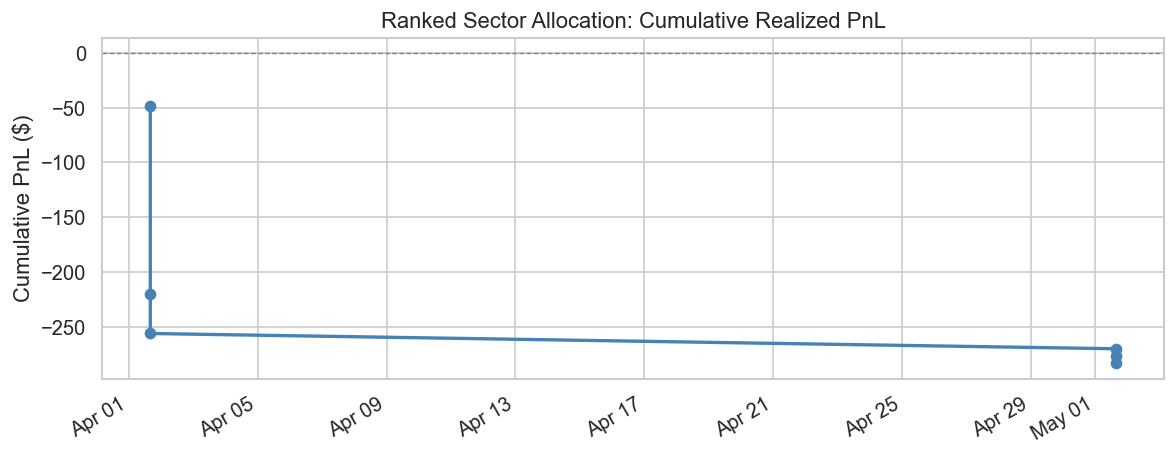

In [8]:
from collections import deque

# FIFO cost basis for ranked orders
cost_basis = {}  # symbol -> deque of (qty, price)
realized_trades = []

for _, row in ranked_filled.iterrows():
    sym = row['Symbol']
    qty = float(row['Filled Qty'])
    price = float(row['Filled Avg Price'])
    side = row['Side']
    date = row['Submitted At']

    if side == 'BUY':
        if sym not in cost_basis:
            cost_basis[sym] = deque()
        cost_basis[sym].append((qty, price))

    elif side == 'SELL':
        pnl = 0.0
        remaining = qty
        entry_price = 0.0
        if sym in cost_basis:
            while remaining > 0 and cost_basis[sym]:
                eq, ep = cost_basis[sym][0]
                take = min(remaining, eq)
                pnl += take * (price - ep)
                entry_price = ep
                remaining -= take
                if take >= eq:
                    cost_basis[sym].popleft()
                else:
                    cost_basis[sym][0] = (eq - take, ep)

        realized_trades.append({
            'date': date,
            'symbol': sym,
            'qty': qty,
            'entry_price': entry_price,
            'exit_price': price,
            'pnl': round(pnl, 2),
            'return_pct': (price / entry_price - 1) if entry_price > 0 else 0,
        })

if realized_trades:
    rt_df = pd.DataFrame(realized_trades)
    print(f"Realized trades: {len(rt_df)}")
    print(f"Total realized PnL: ${rt_df['pnl'].sum():,.2f}")
    print()
    display(rt_df)

    # Cumulative PnL chart
    if len(rt_df) > 1:
        rt_df = rt_df.sort_values('date')
        rt_df['cum_pnl'] = rt_df['pnl'].cumsum()
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(rt_df['date'], rt_df['cum_pnl'], marker='o', lw=2, color='steelblue')
        ax.axhline(0, color='gray', ls='--', lw=0.8)
        ax.set_title('Ranked Sector Allocation: Cumulative Realized PnL')
        ax.set_ylabel('Cumulative PnL ($)')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
        plt.tight_layout()
        plt.show()
else:
    print("No realized trades for ranked strategy yet.")

In [9]:
# Mark-to-market open positions
open_syms = [s for s, q in holdings.items() if q > 0]
if open_syms:
    mtm_data = yf.download(open_syms, period='5d', progress=False)
    mtm_rows = []
    for sym in open_syms:
        try:
            if len(open_syms) == 1:
                last_price = float(mtm_data['Close'].dropna().iloc[-1])
            else:
                last_price = float(mtm_data[sym]['Close'].dropna().iloc[-1])
        except Exception:
            last_price = 0

        shares = holdings[sym]
        # Get avg entry from remaining cost basis
        if sym in cost_basis and cost_basis[sym]:
            avg_entry = sum(q*p for q,p in cost_basis[sym]) / sum(q for q,p in cost_basis[sym])
        else:
            avg_entry = 0

        mtm_pnl = (last_price - avg_entry) * shares if avg_entry > 0 else 0
        mtm_rows.append({
            'symbol': sym,
            'shares': shares,
            'avg_entry': round(avg_entry, 2),
            'last_price': round(last_price, 2),
            'market_value': round(last_price * shares, 2),
            'unrealized_pnl': round(mtm_pnl, 2),
        })

    mtm_df = pd.DataFrame(mtm_rows)
    print("Open ranked positions (mark-to-market):")
    display(mtm_df)
    print(f"\nTotal unrealized PnL: ${mtm_df['unrealized_pnl'].sum():,.2f}")
    total_mv = mtm_df['market_value'].sum()
    print(f"Total market value: ${total_mv:,.2f}")
else:
    print("No open ranked positions.")

Open ranked positions (mark-to-market):


,symbol,shares,avg_entry,last_price,market_value,unrealized_pnl
0,XLP,36.680211,85.20,0,0.0,-3125.00
1,XLU,67.436097,46.34,0,0.0,-3125.00
2,XLC,5.000000,117.12,0,0.0,-585.60
3,XLE,25.000000,58.87,0,0.0,-1471.75
4,XLF,28.000000,52.41,0,0.0,-1467.48
5,XLK,4.000000,161.74,0,0.0,-646.96



Total unrealized PnL: $-10,421.79
Total market value: $0.00


## Data Sensitivity: Live vs Research Downloads

The live strategy downloads 2 years of unadjusted prices (`auto_adjust` defaults to
yfinance behavior). The research pipeline uses 8+ years with `auto_adjust=True`.
This can cause regime and DAF leverage signals to diverge on the same calendar date.

In [10]:
# Compare close prices on overlapping dates
overlap_dates = live_closes.index.intersection(research_closes.index)
if len(overlap_dates) > 0:
    sample_tickers = ['SPY', 'XLK', 'XLF', 'XLE']
    sample_tickers = [t for t in sample_tickers if t in live_closes.columns and t in research_closes.columns]

    if sample_tickers:
        print(f"Price comparison on last 5 overlapping dates ({len(overlap_dates)} total overlap):\n")
        for t in sample_tickers:
            live_p = live_closes[t].loc[overlap_dates[-5:]]
            res_p = research_closes[t].loc[overlap_dates[-5:]]
            diff_pct = ((live_p - res_p) / res_p * 100).round(2)
            comp = pd.DataFrame({
                'Live': live_p.round(2),
                'Research (adj)': res_p.round(2),
                'Diff %': diff_pct,
            })
            print(f"--- {t} ---")
            display(comp)

    # Does regime differ?
    live_regime = _regime(live_closes, len(live_closes)-1, V4_BREADTH)
    # Run regime on research data
    res_regime = _regime(research_closes, len(research_closes)-1, V4_BREADTH)
    print(f"\nRegime on latest date:")
    print(f"  Live data (2y, unadj):     {live_regime}")
    print(f"  Research data (8y+, adj):   {res_regime}")
    print(f"  Same? {'Yes' if live_regime == res_regime else 'NO - DIVERGENCE'}")
else:
    print("No overlapping dates between live and research data.")

No overlapping dates between live and research data.


## Decision Memo

### Key findings

1. The live strategy uses a **buy-new / sell-dropped** execution model without
   weight rebalancing, causing drift from target allocations over time.

2. Data differences (2y unadjusted vs multi-year adjusted) can cause signal
   divergence, particularly in the regime filter and DAF leverage trigger.

3. The live code does not use `auto_adjust=True`, meaning dividend-paying ETFs
   may have slightly different momentum signals vs the research backtest.

### Recommended code changes for live-research parity

| Gap | Fix | Priority |
|-----|-----|----------|
| No weight rebalance | Add trim/top-up logic for existing positions | High |
| `auto_adjust` missing in live download | Add `auto_adjust=True` to `_download_data()` | Medium |
| Rebalance trigger `day <= 3` | Use trading calendar first-business-day check | Low |
| No transaction costs in live signals | Add spread estimate to sizing | Low |

### Recommendation

Keep ranked allocation live while implementing the high-priority weight rebalance fix.
The strategy logic (V4+V8 blend, DAF leverage) is sound, but the execution model
leaks alpha through position drift. Monitor for one more month after the fix, then
compare realized Sharpe against the research backtest.

In [11]:
# Summary statistics
if realized_trades:
    total_realized = sum(t['pnl'] for t in realized_trades)
else:
    total_realized = 0

if open_syms and 'mtm_df' in dir():
    total_unrealized = mtm_df['unrealized_pnl'].sum()
    total_mv_val = mtm_df['market_value'].sum()
else:
    total_unrealized = 0
    total_mv_val = 0

print("=" * 50)
print("RANKED SECTOR ALLOCATION AUDIT SUMMARY")
print("=" * 50)
print(f"Realized PnL:     ${total_realized:>10,.2f}")
print(f"Unrealized PnL:   ${total_unrealized:>10,.2f}")
print(f"Total PnL:        ${total_realized + total_unrealized:>10,.2f}")
print(f"Current MV:       ${total_mv_val:>10,.2f}")
print(f"DAF leverage:     {lev:.1f}x")
print(f"Filled orders:    {len(ranked_filled) if 'ranked_filled' in dir() else 0}")
print(f"Open positions:   {len(open_syms) if open_syms else 0}")
print("=" * 50)

RANKED SECTOR ALLOCATION AUDIT SUMMARY
Realized PnL:     $   -283.26
Unrealized PnL:   $-10,421.79
Total PnL:        $-10,705.05
Current MV:       $      0.00
DAF leverage:     1.0x
Filled orders:    18
Open positions:   6
